In [1]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

In [2]:
!uv pip install -U scikit-learn

Using Python 3.12.13 environment at: /usr
Resolved 7 packages in 354ms
⠙ Preparing packages... (0/6)
⠙ Preparing packages... (0/6)
⠙ Preparing packages... (0/6)
⠙ Preparing packages... (0/6)
threadpoolctl        ------------------------------     0 B/25.74 KiB
⠙ Preparing packages... (0/6)
threadpoolctl        ------------------------------ 14.78 KiB/25.74 KiB
⠙ Preparing packages... (0/6)
threadpoolctl        ------------------------------ 14.78 KiB/25.74 KiB
⠙ Preparing packages... (0/6)
threadpoolctl        ------------------------------ 14.78 KiB/25.74 KiB
⠙ Preparing packages... (0/6)
threadpoolctl        ------------------------------ 14.78 KiB/25.74 KiB
joblib               ------------------------------     0 B/298.94 KiB
⠙ Preparing packages... (0/6)
threadpoolctl        ------------------------------ 14.78 KiB/25.74 KiB
joblib               ------------------------------ 14.75 KiB/298.94 KiB
⠙ Preparing packages... (0/6)
threadpoolctl        ------------------------------ 14.

In [3]:
!pip show scikit-learn

Name: scikit-learn
Version: 1.9.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: joblib, narwhals, numpy, scipy, threadpoolctl
Required-by: bayesian-optimization, Boruta, category_encoders, cesium, esda, fastai, hdbscan, hep_ml, imbalanced-learn, libpysal, librosa, lime, mapclassify, mlxtend, nilearn, pyLDAvis, pynndescent, pysal, rgf-python, scikit-optimize, scikit-plot, segregation, sentence-transformers, shap, sklearn-compat, sklearn-pandas, spopt, spreg, TPOT, tsfresh, umap-learn, woodwork, yellowbrick


In [4]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import TargetEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier

# 1. LOAD DATA

In [5]:
TRAIN_PATH = '/kaggle/input/competitions/playground-series-s6e9/train.csv'
TEST_PATH  = '/kaggle/input/competitions/playground-series-s6e9/test.csv'
SUB_PATH   = '/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv'
ORIG_PATH  = '/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv'

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)
orig  = pd.read_csv(ORIG_PATH)
submission = pd.read_csv(SUB_PATH)

# 2.  FEATURE ENGINEERING

In [6]:
TARGET = 'Will_Buy_EV'
train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})
orig[TARGET] = orig[TARGET].map({'Yes': 1, 'No': 0})

train['is_train'] = 1
test['is_train'] = 0
test[TARGET] = np.nan
combined = pd.concat([train, test], ignore_index=True)
combined.drop(columns=['Number_of_Cars_Owned'], inplace=True, errors='ignore')

cat_cols = combined.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = [c for c in combined.columns if c not in cat_cols + ['id', 'is_train', TARGET]]

# Extract digits from the 10^-4 place up to the 10^3 place
digit_features = []
for c in num_cols:
    for k in range(-4, 4):
        col_name = f"{c}_digit{k}"
        combined[col_name] = (combined[c].fillna(0) // (10**k) % 10).astype('int8')
        digit_features.append(col_name)

# Add the new digit features so they get processed by your frequency/target encoders
num_cols.extend(digit_features)

# Map Original Dataset Target Means
orig_global_mean = orig[TARGET].mean()
for col in cat_cols + num_cols:
    if col in orig.columns:
        real_world_stats = orig.groupby(col, observed=False)[TARGET].mean()
        combined[f"{col}_org_mean"] = combined[col].map(real_world_stats).fillna(orig_global_mean).astype(float)

# Convert Numerics to String Categories
num_to_cat_cols = []
for col in num_cols:
    cat_name = f"{col}_cat"
    combined[cat_name] = combined[col].fillna('NaN').astype(str)
    num_to_cat_cols.append(cat_name)

# Global Frequency Encoding
all_cats = cat_cols + num_to_cat_cols
for col in all_cats:
    freq_mapping = combined[col].value_counts(normalize=True).to_dict()
    combined[f"{col}_fe"] = combined[col].map(freq_mapping).astype(float).fillna(0.0)

# The Mode Collapse Spike
# combined['is_30k_spike'] = (combined['Annual_Income_USD'] == 30000.0).astype('int8')  # Pruned! the XGBoost model do need it
# The Millionaire Cliff (100% buy rate region)
# combined['is_millionaire_cliff'] = (combined['Annual_Income_USD'] >= 170537.0).astype('int8')  # Pruned! the XGBoost model do need it
# The Dead Zone (0% buy rate region)
# combined['is_dead_zone'] = ((combined['Annual_Income_USD'] >= 38000.0) & (combined['Annual_Income_USD'] <= 42000.0)).astype('int8')  # Pruned! the XGBoost model do need it
# Environmental Concern Extremes
combined['is_env_hater'] = (combined['Environmental_Concern_Level'] == 1).astype('int8')

# Markus's "Smooth Keys" (Binned Numerics)
combined['income_exact_int'] = np.floor(combined['Annual_Income_USD']).astype(str)
combined['income100_floor']  = np.floor(combined['Annual_Income_USD'] / 100.0).astype(str)
combined['income1000_floor'] = np.floor(combined['Annual_Income_USD'] / 1000.0).astype(str)
combined['commute_integer']  = np.floor(combined['Daily_Commute_km']).astype(str)
# Adding these 4 new string columns to all_cats so they get Frequency and Target Encoded
all_cats.extend(['income_exact_int', 'income100_floor', 'income1000_floor', 'commute_integer'])

train = combined[combined['is_train'] == 1].drop(columns=['is_train'])
test = combined[combined['is_train'] == 0].drop(columns=['is_train', TARGET])

#  FEATURE DROPPING
# Identify numeric columns to evaluate for correlatio (ignore strings/objects because .corr() will fail on them)
eval_cols = [c for c in train.columns if c not in ['id', TARGET] and pd.api.types.is_numeric_dtype(train[c])]

# Find perfectly correlated features (1.0 correlation)
corr_matrix = train[eval_cols].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] == 1.0)]

# Find constant features (only 1 unique value) in train or test
to_drop_const = [c for c in train.columns if train[c].nunique() == 1] + \
                [c for c in test.columns if test[c].nunique() == 1]

# Combine all bad features into a set to drop
DROP = set(to_drop_corr).union(set(to_drop_const))
DROP = [c for c in DROP if c not in ['id', TARGET]] 

if len(DROP) > 0:
    print(f"   -> Dropping {len(DROP)} redundant/constant features: {DROP}")
    train.drop(columns=DROP, inplace=True, errors='ignore')
    test.drop(columns=DROP, inplace=True, errors='ignore')

FEATURES = [c for c in test.columns if c != 'id']
TARGET_ENCODE_COLS = [c for c in all_cats if c not in DROP] 

print(f"✅ Total Features: {len(FEATURES)}")
print(f"✅ Columns to Target Encode: {len(TARGET_ENCODE_COLS)}")

   -> Dropping 85 redundant/constant features: ['Daily_Commute_km_digit-2', 'Annual_Income_USD_digit-4_cat_fe', 'Environmental_Concern_Level_digit-4_cat', 'Daily_Commute_km_digit3', 'Charging_Stations_Near_Work_digit3_cat', 'Charging_Stations_Near_Work_digit-1', 'Annual_Income_USD_digit-2_cat', 'Charging_Stations_Near_Home_digit3', 'Annual_Income_USD_digit-2_cat_fe', 'Daily_Commute_km_digit3_cat_fe', 'Charging_Stations_Near_Home_digit3_cat_fe', 'Environmental_Concern_Level_digit2', 'Charging_Stations_Near_Home_digit3_cat', 'Age_digit3_cat_fe', 'Environmental_Concern_Level_digit-2', 'Charging_Stations_Near_Work_digit-3_cat_fe', 'Environmental_Concern_Level_digit-3_cat_fe', 'Age_digit-3_cat', 'Environmental_Concern_Level_digit-3_cat', 'Annual_Income_USD_digit-1_cat_fe', 'Environmental_Concern_Level_digit3_cat', 'Age_digit-4_cat_fe', 'Charging_Stations_Near_Home_digit-3', 'Environmental_Concern_Level_digit0', 'Charging_Stations_Near_Home_digit-2_cat_fe', 'Charging_Stations_Near_Work_digit

In [7]:
# ==========================================
# MANUAL FEATURE PRUNING (Calculated via Gain Thresholding)
# ==========================================
print("✂️ Feature for dynamic pruning (Dropping 88 low-gain features)...")

features_to_drop = [
    'Age', 'Daily_Commute_km_digit-3_cat_TE_100', 'Charging_Stations_Near_Home_digit0',
    'Daily_Commute_km_digit1_cat_TE_100', 'Annual_Income_USD_digit1', 'Charging_Stations_Near_Work_digit1_cat_TE_auto',
    'Daily_Commute_km_digit1_cat_TE_auto', 'Daily_Commute_km_digit0_cat_TE_10', 'Gender_org_mean',
    'Daily_Commute_km_digit-4_cat_TE_100', 'Daily_Commute_km_digit0_cat_TE_auto', 'Daily_Commute_km_digit-4_cat_TE_auto',
    'Daily_Commute_km_cat_fe', 'Annual_Income_USD_digit1_cat_fe', 'Charging_Stations_Near_Work_digit0_cat_TE_100',
    'Annual_Income_USD_digit2_cat_TE_100', 'Annual_Income_USD_digit0', 'Charging_Stations_Near_Home_digit-3_cat_TE_auto',
    'Gender_TE_100', 'Current_Car_Type_TE_10', 'Age_digit1_cat_fe', 'Charging_Stations_Near_Work_digit1_cat_TE_100',
    'Annual_Income_USD_digit0_cat_TE_10', 'Daily_Commute_km_digit-3_cat_TE_10', 'Charging_Stations_Near_Work_digit0_cat_TE_10',
    'Gender_TE_auto', 'Daily_Commute_km_digit0_cat_TE_100', 'Charging_Stations_Near_Home_digit-4_cat_TE_auto',
    'Daily_Commute_km_digit-1_cat_TE_10', 'Charging_Stations_Near_Work_digit0_cat_TE_auto', 'Daily_Commute_km_digit-1',
    'Charging_Stations_Near_Work_digit0', 'Annual_Income_USD_digit0_cat_TE_auto', 'Daily_Commute_km_digit-4_cat_TE_10',
    'Charging_Stations_Near_Work_digit-3_cat_TE_auto', 'Charging_Stations_Near_Work_org_mean', 'Age_digit0_cat_TE_auto',
    'Age_digit0_cat_fe', 'Annual_Income_USD_digit0_cat_fe', 'Charging_Stations_Near_Home_digit-4_cat_TE_100',
    'Daily_Commute_km_digit-3_cat_TE_auto', 'Age_digit0', 'Annual_Income_USD_digit2_cat_TE_auto',
    'Annual_Income_USD_digit0_cat_TE_100', 'Daily_Commute_km_org_mean', 'Age_digit0_cat_TE_10',
    'Current_Car_Type_TE_auto', 'Current_Car_Type_TE_100', 'Age_digit1_cat_TE_auto', 'Charging_Stations_Near_Home_digit-4',
    'Annual_Income_USD_digit2_cat_TE_10', 'Daily_Commute_km_digit-1_cat_TE_100', 'Age_cat_fe',
    'Daily_Commute_km_digit0_cat_fe', 'Daily_Commute_km_digit-1_cat_fe', 'Daily_Commute_km_digit-1_cat_TE_auto',
    'Daily_Commute_km_digit-2_cat_TE_10', 'Age_digit1', 'Age_digit1_cat_TE_100', 'Gender_TE_10', 'Age_digit1_cat_TE_10',
    'Age_digit0_cat_TE_100', 'Daily_Commute_km_digit-3', 'Charging_Stations_Near_Home_digit-3_cat_TE_100', 'Gender_fe',
    'Charging_Stations_Near_Home_digit-3_cat_TE_10', 'Daily_Commute_km_digit-4_cat_fe', 'Daily_Commute_km_digit-4',
    'Daily_Commute_km_digit-3_cat_fe', 'Charging_Stations_Near_Work_digit-3_cat_TE_10', 'Daily_Commute_km_digit-2_cat_TE_100',
    'Charging_Stations_Near_Home_digit-2_cat_TE_auto', 'Charging_Stations_Near_Home_digit-1_cat_TE_auto',
    'Charging_Stations_Near_Work_digit1_cat_fe', 'Charging_Stations_Near_Work_digit-2_cat_TE_100',
    'Charging_Stations_Near_Home_digit-2_cat_TE_100', 'Charging_Stations_Near_Work_digit-3_cat_TE_100', 'is_dead_zone',
    'is_millionaire_cliff', 'is_30k_spike', 'Charging_Stations_Near_Home_digit-1_cat_TE_100',
    'Charging_Stations_Near_Home_digit-1_cat_TE_10', 'Charging_Stations_Near_Home_digit-2_cat_TE_10',
    'Charging_Stations_Near_Work_digit-1_cat_TE_10', 'Charging_Stations_Near_Work_digit-2_cat_TE_auto',
    'Charging_Stations_Near_Work_digit-1_cat_TE_auto', 'Charging_Stations_Near_Work_digit-1_cat_TE_100',
    'Charging_Stations_Near_Work_digit-2_cat_TE_10'
]

✂️ Feature for dynamic pruning (Dropping 88 low-gain features)...


# 3. 10 FOLD CV WITH SKLEARN TARGET ENCODING

In [8]:
%%time

FOLDS = 10
print(f"\n🚀 Training HistGradient with {FOLDS} Folds...")

X = train[FEATURES]
y = train[TARGET]
X_test = test[FEATURES]

skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(train))
test_preds = np.zeros(len(test))

# feature_importances = pd.DataFrame()

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), 1):
    X_train, y_train = X.iloc[train_idx].copy(), y.iloc[train_idx]
    X_valid, y_valid = X.iloc[valid_idx].copy(), y.iloc[valid_idx]
    X_test_fold = X_test.copy()

    # Triple Sklearn Target Encoders (Auto, Strict 10, and Massive 100)
    te_auto = TargetEncoder(shuffle=True, cv=5, smooth='auto', random_state=42)
    te_10   = TargetEncoder(shuffle=True, cv=5, smooth=10.0, random_state=42)
    te_100  = TargetEncoder(shuffle=True, cv=5, smooth=100.0, random_state=42)

    X_train_enc_auto = te_auto.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
    X_valid_enc_auto = te_auto.transform(X_valid[TARGET_ENCODE_COLS])
    X_test_enc_auto  = te_auto.transform(X_test_fold[TARGET_ENCODE_COLS])

    X_train_enc_10 = te_10.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
    X_valid_enc_10 = te_10.transform(X_valid[TARGET_ENCODE_COLS])
    X_test_enc_10  = te_10.transform(X_test_fold[TARGET_ENCODE_COLS])

    X_train_enc_100 = te_100.fit_transform(X_train[TARGET_ENCODE_COLS], y_train)
    X_valid_enc_100 = te_100.transform(X_valid[TARGET_ENCODE_COLS])
    X_test_enc_100  = te_100.transform(X_test_fold[TARGET_ENCODE_COLS])

    for i, col in enumerate(TARGET_ENCODE_COLS):
        # Auto smoothing TE
        X_train[f"{col}_TE_auto"] = X_train_enc_auto[:, i].astype('float32')
        X_valid[f"{col}_TE_auto"] = X_valid_enc_auto[:, i].astype('float32')
        X_test_fold[f"{col}_TE_auto"] = X_test_enc_auto[:, i].astype('float32')
        
        # Strict (10.0) smoothing TE
        X_train[f"{col}_TE_10"] = X_train_enc_10[:, i].astype('float32')
        X_valid[f"{col}_TE_10"] = X_valid_enc_10[:, i].astype('float32')
        X_test_fold[f"{col}_TE_10"] = X_test_enc_10[:, i].astype('float32')

        # Massive (100.0) smoothing TE (Markus's method)
        X_train[f"{col}_TE_100"] = X_train_enc_100[:, i].astype('float32')
        X_valid[f"{col}_TE_100"] = X_valid_enc_100[:, i].astype('float32')
        X_test_fold[f"{col}_TE_100"] = X_test_enc_100[:, i].astype('float32')
        
        # Drop the original string column
        X_train.drop(columns=[col], inplace=True)
        X_valid.drop(columns=[col], inplace=True)
        X_test_fold.drop(columns=[col], inplace=True)
        
    # APPLY DYNAMIC PRUNING
    if len(features_to_drop) > 0:
        # Check X_train.columns because it contains both base features and the new _TE_ features
        safe_to_drop = [c for c in features_to_drop if c in X_train.columns]
        
        if len(safe_to_drop) > 0:
            if fold == 1:
                print(f"   -> Successfully pruned {len(safe_to_drop)} features.")
                
            X_train.drop(columns=safe_to_drop, inplace=True, errors='ignore')
            X_valid.drop(columns=safe_to_drop, inplace=True, errors='ignore')
            X_test_fold.drop(columns=safe_to_drop, inplace=True, errors='ignore')

    # --- TUNED HISTGRADIENT MODEL ---
    clf = HistGradientBoostingClassifier(
        max_iter=500,
        max_depth=16,
        learning_rate=0.05,
        l2_regularization=1.0,
        min_samples_leaf=100,
        n_iter_no_change=50,
        # max_features=0.9,
        random_state=42,
        verbose=1,
    )

    clf.fit(X_train, y_train, X_val=X_valid, y_val=y_valid)

    oof_preds[valid_idx] = clf.predict_proba(X_valid)[:, 1]
    test_preds += clf.predict_proba(X_test_fold)[:, 1] / FOLDS

    fold_auc = roc_auc_score(y_valid, oof_preds[valid_idx])
    print(f"   --> Fold {fold} AUC: {fold_auc:.6f}")

oof_auc = roc_auc_score(y, oof_preds)

print("\n" + "="*45)
print(f"🏆 HISTGRADIENT FINAL OOF AUC: {oof_auc:.6f}")
print("="*45)


🚀 Training HistGradient with 10 Folds...
   -> Successfully pruned 85 features.
Binning 0.496 GB of training data: 2.254 s
Binning 0.055 GB of validation data: 0.114 s
Fitting gradient boosted rounds:
Fit 408 trees in 84.213 s, (12648 total leaves)
Time spent computing histograms: 69.948s
Time spent finding best splits:  1.288s
Time spent applying splits:      2.801s
Time spent predicting:           0.639s
   --> Fold 1 AUC: 0.944913
Binning 0.496 GB of training data: 2.275 s
Binning 0.055 GB of validation data: 0.111 s
Fitting gradient boosted rounds:
Fit 500 trees in 100.068 s, (15500 total leaves)
Time spent computing histograms: 83.564s
Time spent finding best splits:  1.538s
Time spent applying splits:      3.152s
Time spent predicting:           0.748s
   --> Fold 2 AUC: 0.945228
Binning 0.496 GB of training data: 2.249 s
Binning 0.055 GB of validation data: 0.113 s
Fitting gradient boosted rounds:
Fit 424 trees in 88.390 s, (13144 total leaves)
Time spent computing histograms: 

In [9]:
# =============================================
# 🏆 HISTGRADIENT FINAL OOF AUC: 0.945617
# =============================================

# 4. SAVE SUBMISSION AND OOF PREDICTIONS

In [10]:
print("\n" + "="*45)
print(f"🏆 HISTGRADIENT FINAL OOF ROC-AUC: {oof_auc:.6f}")
print("="*45)

MODEL_NAME = "HISTGRADIENT_Triple_TE"

# Save Kaggle Submission (Averaged Test Predictions)
submission[TARGET] = test_preds
submission.to_csv(f"submission_{MODEL_NAME}_{oof_auc:.6f}.csv", index=False)
print(f"💾 Saved 'submission_{MODEL_NAME}_{oof_auc:.6f}.csv'")

# Save Raw Test Predictions (for ensembling)
test_df = pd.DataFrame({'id': test['id'], TARGET: test_preds})
# test_df.to_csv(f'test_{MODEL_NAME}.csv', index=False)
np.save(f"test_{MODEL_NAME}_{oof_auc:.6f}.npy", test_preds)
print(f"💾 Saved 'test_{MODEL_NAME}_{oof_auc:.6f}.npy'")

# Save OOF Predictions (for ensembling meta-model)
oof_df = pd.DataFrame({'id': train['id'], 'OOF_Pred': oof_preds})
# oof_df.to_csv(f'oof_{MODEL_NAME}.csv', index=False)
np.save(f"oof_{MODEL_NAME}_{oof_auc:.6f}.npy", oof_preds)
print(f"💾 Saved 'oof_{MODEL_NAME}_{oof_auc:.6f}.npy'")

# feature_importances = feature_importances.sort_values(by='importance', ascending=False).reset_index(drop=True)
# # feature_importances.to_csv(f'feature_importance_{MODEL_NAME}.csv', index=False)
# print(f"💾 Saved 'feature_importance_{MODEL_NAME}.csv'")

# # Print the top 10 and bottom 10 features
# print("\n🔥 Top 10 Features:")
# print(feature_importances.head(10))
# print("\n🧊 Bottom 10 Features (Candidates for Pruning):")
# print(feature_importances.tail(10))


🏆 HISTGRADIENT FINAL OOF ROC-AUC: 0.946021
💾 Saved 'submission_HISTGRADIENT_Triple_TE_0.946021.csv'
💾 Saved 'test_HISTGRADIENT_Triple_TE_0.946021.npy'
💾 Saved 'oof_HISTGRADIENT_Triple_TE_0.946021.npy'


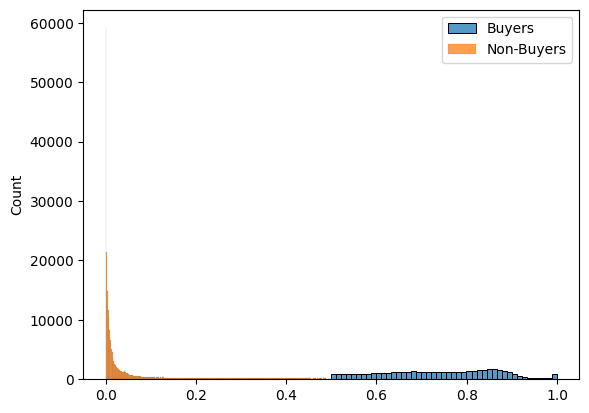

In [11]:
buyers = test_preds[test_preds >= 0.5]
non_buyers = test_preds[test_preds < 0.5]

sns.histplot(buyers, label="Buyers")
sns.histplot(non_buyers, label="Non-Buyers")
plt.legend()
plt.show()

In [12]:
# !rm -r /kaggle/working/